Title: LEE_Detection_bc_old.ipynb

Purpose: Identifiy Low Energy Events with varying lengths from the model output data

Author: Onno Nennecke on 21.03.2025 Modified: 28.06.2025

Input data: 

- adjusted final model output    - This file lies here: 

Output data:

- LEE Tables    - This file lies here: 

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob

# Importing functions

### Read Model output data

In [2]:
path = '/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/'
files = sorted(glob.glob(path + '*.nc'))
# files = files[:60] + files[61:]
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim = 'ESM_run')
ts_datasets.coords['doy'] = (('time',), np.tile(np.arange(1, 366), 10))

ts_datasets

<xarray.Dataset> Size: 31MB
Dimensions:        (ESM_run: 101, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    country        float64 8B 9.0
    period         <U4 16B 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    demand         (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    sfcWind        (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    rsds           (ESM_run, time) float32 1MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    tas            (ESM_run, time) float32 1MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    tasmax         (ESM_run, time) float32 1MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    Netto          (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 3MB dask.array<chunksize=(1, 3650), meta=np.ndarray>

In [3]:
# ts_datasets['ESM'].values

#### Identification of low energy events

In [3]:
# RL = ts_datasets['Residual_load_adj']
RL = ts_datasets['Residual_load']

RL.values

array([[ 787.63612406,  924.66670791, 1003.62752591, ..., 1269.59903474,
        1129.73550146,  775.24114231],
       [ 643.08569757,  636.39581809,  660.167093  , ...,  899.8177478 ,
         430.1484025 ,    2.56361165],
       [ 576.56631125,  955.70919585, 1218.27628286, ..., 1327.6518259 ,
        1290.1692648 ,  664.42802334],
       ...,
       [1285.19082167, 1256.94124436, 1373.11996691, ..., 1224.48901052,
        1297.14828168, 1403.46300586],
       [ 723.26069019,  249.61417615, -123.44668672, ..., 1336.08178081,
        1444.14826593, 1272.20065263],
       [ 856.05192697, 1187.74430271, 1059.96451083, ...,  890.44086419,
         236.87520917,  335.25862639]])

In [4]:
# Calculate the rolling means
ts_datasets['RL_mov_avg_7'] = RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
ts_datasets['RL_mov_avg_14'] = RL_mov_avg_14 = RL.rolling(time=14, center=False).mean()
# ts_datasets

In [5]:
ts_datasets.load()

<xarray.Dataset> Size: 37MB
Dimensions:        (ESM_run: 101, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run        (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    country        float64 8B 9.0
    period         <U4 16B 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables: (12/14)
    temp           (ESM_run, time) float64 3MB 5.353 2.449 0.1301 ... 8.08 6.186
    demand         (ESM_run, time) float64 3MB 1.453e+03 1.49e+03 ... 1.443e+03
    sfcWind        (ESM_run, time) float64 3MB 8.758 6.495 6.995 ... 10.64 9.913
    rsds           (ESM_run, time) float32 1MB 12.7 23.48 36.6 ... 16.02 20.55
    tas            (ESM_run, time) float32 1MB 4.07 1.36 -0.4772 ... 7.579 6.099
    tasmax         (ESM_run, time) float32 1MB 6.131 2.73 1.05 ... 9.851 7.746
    ...             ...
    solar_prod     (ESM_run, time) float64 3MB 31.95 62.57 104.9 ... 44.84 57.99
    total_prod     (ESM_run, time) float64 3MB 665.7 565.0 ... 1.108e+03
    Netto          (ESM_run, time) float64 3MB -787.6 -924.7 ... -236.9 -335.3
    Residual_load  (ESM_run, time) float64 3MB 787.6 924.7 ... 236.9 335.3
    RL_mov_avg_7   (ESM_run, time) float64 3MB nan nan nan ... 556.4 419.7 382.5
    RL_mov_avg_14  (ESM_run, time) float64 3MB nan nan nan ... 863.9 794.9 755.2

In [7]:
# 95 percentile per run (not really needed)
'''
# Initialize an empty DataArray for storing 95th percentiles
perc_95 = xr.DataArray(np.zeros(len(RL.ESM)), dims="ESM_run", coords={"ESM_run": RL.ESM_run})

# Compute 95th percentile for each ESM_run
for i in RL.ESM_run.values:
    RL_run = RL.sel(ESM_run=i)
    perc_95.loc[i] = np.percentile(RL_run.values, 95)
# perc_95
# import matplotlib.pyplot as plt

# # Plot histogram of the 95th percentiles
# plt.hist(perc_95.values, bins=20, edgecolor='k')
# plt.xlabel('95th Percentile Values')
# plt.ylabel('Frequency')
# plt.title('Histogram of 95th Percentiles')
# plt.show()
'''

# 95 percentile all runs
'''
RL.to_dataframe(name="Residual_load").describe()
np.percentile(RL.values, [5, 25, 50, 75, 95])
'''


'\nRL.to_dataframe(name="Residual_load").describe()\nnp.percentile(RL.values, [5, 25, 50, 75, 95])\n'

In [6]:
# Time series of "True" when threshold is exceeded, "False" otherwise
# perc_95_all = np.percentile(RL.values, [95])
# print(perc_95_all)
# exceed_bool = RL - perc_95_all
# exceed_bool = xr.where(exceed_bool > 0, True, False)

threshold = np.quantile(RL.values.flatten(), 0.95)
print(threshold)
exceed_bool_1 = xr.where(RL > threshold, True, False)
exceed_bool_7 = xr.where(RL_mov_avg_7 > threshold, True, False)
exceed_bool_14 = xr.where(RL_mov_avg_14 > threshold, True, False)


1320.473093962827


In [7]:
exceed_bool_1.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ...,  True, False, False],
       ...,
       [False, False,  True, ..., False, False,  True],
       [False, False, False, ...,  True,  True, False],
       [False, False, False, ..., False, False, False]])

In [8]:
# Look for events without any rolling mean


# Count number of true values overall
count_exceed_1 = exceed_bool_1.sum(dim='time').sum(dim='ESM_run')
count_exceed_1.values
# exceed_bool_1.time
# np.zeros_like(exceed_bool_1, dtype=int)

array(18433)

In [9]:
exceed_bool_1

<xarray.DataArray 'Residual_load' (ESM_run: 101, time: 3650)> Size: 369kB
dask.array<where, shape=(101, 3650), dtype=bool, chunksize=(1, 3650), chunktype=numpy.ndarray>
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
    country   float64 8B 9.0
    period    <U4 16B 'week'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

### Days above threshold (dat) 

- Take each day as its own event (not really events but just days above threshold)

In [10]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_1.values)
n_dat = run_idx.size

# 2) Create a flat counter 1…n_dat
labels = np.arange(1, n_dat + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat = np.zeros_like(exceed_bool_1.values, dtype=int)
dat[run_idx, time_idx] = labels

# wrap back into an xarray
dat = xr.DataArray(
    dat,
    coords=exceed_bool_1.coords,
    dims=exceed_bool_1.dims,
    name="dat"
)

n_dat = n_dat
dat

<xarray.DataArray 'dat' (ESM_run: 101, time: 3650)> Size: 3MB
array([[    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,   499,     0,     0],
       ...,
       [    0,     0, 17992, ...,     0,     0, 18111],
       [    0,     0,     0, ..., 18262, 18263,     0],
       [    0,     0,     0, ...,     0,     0,     0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
    country   float64 8B 9.0
    period    <U4 16B 'week'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

### Events with rolling mean of 1 above threshold (events_vl) = events with varying length 

In [ ]:
# Look for events without any rolling mean

events_vl = np.zeros_like(exceed_bool_1, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
for run in exceed_bool_1.ESM_run.values:
    run_data = exceed_bool_1.sel(ESM_run=run)
    # Only label this section
    labeled_segment, num_features = ndimage.label(run_data.values)

    if num_features > 0:
        labeled_segment[labeled_segment > 0] += current_label - 1
        current_label += num_features

    # Save the label to the result array
    events_vl[counter] = labeled_segment
    counter += 1

n_events_vl = current_label - 1
n_events_vl



8767

In [32]:
len(labeled_segment)

3650

In [28]:
events_vl

array([[   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,  250,    0,    0],
       ...,
       [   0,    0, 8540, ...,    0,    0, 8609],
       [   0,    0,    0, ..., 8683, 8683,    0],
       [   0,    0,    0, ...,    0,    0,    0]])

In [ ]:
'''# Look for events without any rolling mean

events_vl = np.zeros_like(exceed_bool_1, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
run_years = np.unique(exceed_bool_1.time.dt.year.values)

for run in exceed_bool_1.ESM_run.values:
    run_data = exceed_bool_1.sel(ESM_run=run)
    
    for year in run_years:
        # Mask this year inside of this run
        year_mask = run_data.time.dt.year.values == year

        # Only label this section
        labeled_segment, num_features = ndimage.label(run_data.values * year_mask)

        if num_features > 0:
            labeled_segment[labeled_segment > 0] += current_label - 1
            current_label += num_features

        # Save the label to the result array
        events_vl[counter, year_mask] = labeled_segment[year_mask]
    counter += 1

events_vl
n_events_vl = current_label - 1
n_events_vl
'''

8834

### Events with rolling mean of 7 above thresold (events_7) 

In [16]:
exceed_bool_7
exceed_bool_7.sum(dim='time').sum(dim='ESM_run').values

array(5066)

In [17]:
exceed_bool_7.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False, False]])

In [33]:
# Look for events with rolling mean of 7 days

events_7 = np.zeros_like(exceed_bool_7, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
for run in exceed_bool_7.ESM_run.values:
    run_data = exceed_bool_7.sel(ESM_run=run)
    # Only label this section
    labeled_segment, num_features = ndimage.label(run_data.values)

    if num_features > 0:
        labeled_segment[labeled_segment > 0] += current_label - 1
        current_label += num_features

    # Save the label to the result array
    events_7[counter] = labeled_segment
    counter += 1

n_events_7 = current_label - 1
n_events_7

1275

In [34]:
'''# Look for events with rolling mean of 7 days

events_7 = np.zeros_like(exceed_bool_7, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
run_years = np.unique(exceed_bool_7.winter_year.values)

for run in exceed_bool_7.ESM_run.values:
    run_data = exceed_bool_7.sel(ESM_run=run)
    
    for year in run_years:
        # Mask this winter_year inside of this run
        year_mask = run_data.winter_year.values == year

        # Only label this section
        labeled_segment, num_features = ndimage.label(run_data.values * year_mask)

        if num_features > 0:
            labeled_segment[labeled_segment > 0] += current_label - 1
            current_label += num_features

        # Save the label to the result array
        events_7[counter, year_mask] = labeled_segment[year_mask]
    counter += 1

events_7
n_events_7 = current_label - 1
n_events_7'''

'# Look for events with rolling mean of 7 days\n\nevents_7 = np.zeros_like(exceed_bool_7, dtype=int)\n\n# Starting value for the labels\ncurrent_label = 1\ncounter = 0\nrun_years = np.unique(exceed_bool_7.winter_year.values)\n\nfor run in exceed_bool_7.ESM_run.values:\n    run_data = exceed_bool_7.sel(ESM_run=run)\n\n    for year in run_years:\n        # Mask this winter_year inside of this run\n        year_mask = run_data.winter_year.values == year\n\n        # Only label this section\n        labeled_segment, num_features = ndimage.label(run_data.values * year_mask)\n\n        if num_features > 0:\n            labeled_segment[labeled_segment > 0] += current_label - 1\n            current_label += num_features\n\n        # Save the label to the result array\n        events_7[counter, year_mask] = labeled_segment[year_mask]\n    counter += 1\n\nevents_7\nn_events_7 = current_label - 1\nn_events_7'

### Events with rolling mean of 14 above thresold (events_14) 

In [35]:
exceed_bool_14
exceed_bool_14.sum(dim='time').sum(dim='ESM_run')

<xarray.DataArray 'Residual_load' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=int64, chunksize=(), chunktype=numpy.ndarray>
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U4 16B 'week'

In [36]:
# Look for events with rolling mean of 14 days

events_14 = np.zeros_like(exceed_bool_14, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
for run in exceed_bool_14.ESM_run.values:
    run_data = exceed_bool_14.sel(ESM_run=run)
    # Only label this section
    labeled_segment, num_features = ndimage.label(run_data.values)

    if num_features > 0:
        labeled_segment[labeled_segment > 0] += current_label - 1
        current_label += num_features

    # Save the label to the result array
    events_14[counter] = labeled_segment
    counter += 1

n_events_14 = current_label - 1
n_events_14

319

In [ ]:
'''# Look for events with rolling mean of 14 days

events_14 = np.zeros_like(exceed_bool_14, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
run_years = np.unique(exceed_bool_14.winter_year.values)

for run in exceed_bool_14.ESM_run.values:
    run_data = exceed_bool_14.sel(ESM_run=run)
    
    for year in run_years:
        # Mask this winter_year inside of this run
        year_mask = run_data.winter_year.values == year

        # Only label this section
        labeled_segment, num_features = ndimage.label(run_data.values * year_mask)

        if num_features > 0:
            labeled_segment[labeled_segment > 0] += current_label - 1
            current_label += num_features

        # Save the label to the result array
        events_14[counter, year_mask] = labeled_segment[year_mask]
    counter += 1

events_14
n_events_14 = current_label - 1
n_events_14'''

70

In [13]:
# Old code without iterating over the years individually (actually didn't produce different results but the other way is cleaner (in case there would be a late spring and early autumn event this might not be captured by this code))
'''
events_1 = np.zeros_like(exceed_bool_1, dtype=int)

# Startwert für fortlaufende Labels
current_label = 1

# Pro Zeile (run) durchgehen
for i in range(exceed_bool_1.shape[0]):
    labels_line, num_features = ndimage.label(exceed_bool_1[i].values)  # 1D labeling
    if num_features > 0:
        labels_line[labels_line > 0] += current_label - 1  # Offset anwenden
        current_label += num_features
    events_1[i, :] = labels_line

events_1
n_events_1 = current_label - 1
n_events_1
'''

'\nevents_1 = np.zeros_like(exceed_bool_1, dtype=int)\n\n# Startwert für fortlaufende Labels\ncurrent_label = 1\n\n# Pro Zeile (run) durchgehen\nfor i in range(exceed_bool_1.shape[0]):\n    labels_line, num_features = ndimage.label(exceed_bool_1[i].values)  # 1D labeling\n    if num_features > 0:\n        labels_line[labels_line > 0] += current_label - 1  # Offset anwenden\n        current_label += num_features\n    events_1[i, :] = labels_line\n\nevents_1\nn_events_1 = current_label - 1\nn_events_1\n'

In [37]:
# events_vl
print(n_events_vl)
# events_7
print(n_events_7)
# events_14
print(n_events_14)

8767
1275
319


In [ ]:
# events_vl
print(n_events_vl)
# events_7
print(n_events_7)
# events_14
print(n_events_14)

5326
478
70


In [15]:
'''LEE = {}
LEE['date_start'] = [] # datetime format
LEE['date_end'] = [] # datetime format
LEE['date_peak'] = [] # datetime format
LEE['index_start'] = []
LEE['index_end'] = []
LEE['index_peak'] = []
LEE['duration'] = [] # [days]
LEE['RL_max'] = []
LEE['RL_mean'] = []
LEE['RL_var'] = []
LEE['RL_cumulative'] = [] # energy deficit or drought severity
LEE['ESM'] = []
LEE['ESM_run'] = []
LEE['winter'] = []
# maybe:
LEE['prod_max'] = []
LEE['prod_mean'] = []
LEE['prod_var'] = []
LEE['prod_cumulative'] = []
LEE['demand_max'] = []
LEE['demand_mean'] = []
LEE['demand_var'] = []
LEE['demand_cumulative'] = []
LEE['pot_max'] = []
LEE['pot_mean'] = []
LEE['pot_var'] = []
LEE['pot_cumulative'] = []
'''


"LEE = {}\nLEE['date_start'] = [] # datetime format\nLEE['date_end'] = [] # datetime format\nLEE['date_peak'] = [] # datetime format\nLEE['index_start'] = []\nLEE['index_end'] = []\nLEE['index_peak'] = []\nLEE['duration'] = [] # [days]\nLEE['RL_max'] = []\nLEE['RL_mean'] = []\nLEE['RL_var'] = []\nLEE['RL_cumulative'] = [] # energy deficit or drought severity\nLEE['ESM'] = []\nLEE['ESM_run'] = []\nLEE['winter'] = []\n# maybe:\nLEE['prod_max'] = []\nLEE['prod_mean'] = []\nLEE['prod_var'] = []\nLEE['prod_cumulative'] = []\nLEE['demand_max'] = []\nLEE['demand_mean'] = []\nLEE['demand_var'] = []\nLEE['demand_cumulative'] = []\nLEE['pot_max'] = []\nLEE['pot_mean'] = []\nLEE['pot_var'] = []\nLEE['pot_cumulative'] = []\n"

In [60]:
events_7

array([[   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       ...,
       [   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0, 1260,    0],
       [   0,    0,    0, ...,    0,    0,    0]])

In [61]:
def LEE_detection(events, n_events, t=RL['time'].values, minDuration=1):
    LEE_records = []

    for i in range(len(RL.ESM_run)):
        for ev in range(1, n_events + 1):
            event_duration = (events[i] == ev).sum()
            if event_duration < minDuration:
                continue

            start_idx = np.where(events[i] == ev)[0][0]
            end_idx = np.where(events[i] == ev)[0][-1]

            date_start = t[start_idx]
            date_end = t[end_idx]

            LEE_start = np.where(t == date_start)[0][0]
            LEE_end = np.where(t == date_end)[0][0]

            RL_run = RL.sel(ESM_run=RL.ESM_run[i]).values
            RL_LEE = RL_run[LEE_start:LEE_end + 1]
            LEE_peak = np.argmax(RL_LEE)

            record = {
                'date_start': date_start,
                'date_end': date_end,
                'date_peak': date_start + LEE_peak,
                # 'date_start_old': RL['old_time'][i][LEE_start].values,
                # 'date_end_old': RL['old_time'][i][LEE_end].values,
                # 'date_peak_old': RL['old_time'][i][LEE_start + LEE_peak].values,
                'index_start': LEE_start,
                'index_end': LEE_end,
                'index_peak': LEE_start + LEE_peak,
                'duration': len(RL_LEE),
                'RL_max': RL_LEE[LEE_peak],
                'RL_mean': RL_LEE.mean(),
                'RL_var': np.sqrt(RL_LEE.var()),
                'RL_cumulative': RL_LEE.sum(),
                'event': ev,
                'ESM': str(RL.ESM[i].values),
                'ESM_run': str(RL.ESM_run[i].values),
                'year': RL.time.dt.year[start_idx].values,
                'doy' : RL.doy[start_idx].values#,
                # 'winter': RL.winter_year[start_idx].values,
                # 'day_of_winter': RL.day_of_winter[start_idx].values
            }

            # # Optional additional metrics if available
            # # (you could generalize this to loop over var names too)
            # for var in ['prod', 'demand', 'pot']:
            #     try:
            #         var_data = RL[var].sel(ESM_run=RL.ESM_run[i]).values[LEE_start:LEE_end + 1]
            #         record[f'{var}_max'] = var_data.max()
            #         record[f'{var}_mean'] = var_data.mean()
            #         record[f'{var}_var'] = np.sqrt(var_data.var())
            #         record[f'{var}_cumulative'] = var_data.sum()
            #     except KeyError:
            #         pass  # Variable doesn't exist, skip

            LEE_records.append(record)

    return pd.DataFrame(LEE_records)


In [40]:
LEE_dat = LEE_detection(dat, n_dat)

In [60]:
# LEE_dat.to_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_dat.csv', index=False)
LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1366.529785,1366.529785,0.0,1366.529785,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1358.791834,1358.791834,0.0,1358.791834,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1403.613449,1403.613449,0.0,1403.613449,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1391.670797,1391.670797,0.0,1391.670797,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1394.996621,1394.996621,0.0,1394.996621,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18428,2024-01-27,2024-01-27,2024-01-27,3311,3311,3311,1,1343.163035,1343.163035,0.0,1343.163035,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,27
18429,2024-10-24,2024-10-24,2024-10-24,3581,3581,3581,1,1334.281033,1334.281033,0.0,1334.281033,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,297
18430,2024-11-16,2024-11-16,2024-11-16,3604,3604,3604,1,1362.699375,1362.699375,0.0,1362.699375,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,320
18431,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1360.416107,1360.416107,0.0,1360.416107,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,354


In [62]:
LEE_vl = LEE_detection(events_vl, n_events_vl)
LEE_vl

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05 00:00:00.000000000,4,4,4,1,1366.529785,1366.529785,0.000000,1366.529785,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-08,2015-01-07 00:00:00.000000001,6,7,7,2,1403.613449,1381.202641,22.410807,2762.405283,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-18,2015-01-19,2015-01-18 00:00:00.000000001,17,18,18,2,1394.996621,1393.333709,1.662912,2786.667418,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
3,2015-01-23,2015-01-23,2015-01-23 00:00:00.000000000,22,22,22,1,1328.290372,1328.290372,0.000000,1328.290372,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,23
4,2015-10-21,2015-10-21,2015-10-21 00:00:00.000000000,293,293,293,1,1333.760684,1333.760684,0.000000,1333.760684,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8762,2024-01-07,2024-01-07,2024-01-07 00:00:00.000000000,3291,3291,3291,1,1357.141659,1357.141659,0.000000,1357.141659,8763,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,7
8763,2024-01-27,2024-01-27,2024-01-27 00:00:00.000000000,3311,3311,3311,1,1343.163035,1343.163035,0.000000,1343.163035,8764,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,27
8764,2024-10-24,2024-10-24,2024-10-24 00:00:00.000000000,3581,3581,3581,1,1334.281033,1334.281033,0.000000,1334.281033,8765,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,297
8765,2024-11-16,2024-11-16,2024-11-16 00:00:00.000000000,3604,3604,3604,1,1362.699375,1362.699375,0.000000,1362.699375,8766,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,320


In [ ]:
LEE_vl = LEE_detection(events_vl, n_events_vl)
LEE_vl

,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
0,2015-01-18 12:00:00,2015-01-18 12:00:00,2015-01-18 12:00:00,1421582400000000000,1421582400000000000,1421582400000000000,17,17,17,1,1373.585419,1373.585419,0.0,1373.585419,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2014,110
1,2015-10-21 12:00:00,2015-10-21 12:00:00,2015-10-21 12:00:00,1445428800000000000,1445428800000000000,1445428800000000000,110,110,110,1,1378.601098,1378.601098,0.0,1378.601098,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,21
2,2015-11-04 12:00:00,2015-11-04 12:00:00,2015-11-04 12:00:00,1446638400000000000,1446638400000000000,1446638400000000000,124,124,124,1,1404.935534,1404.935534,0.0,1404.935534,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,35
3,2015-11-05 12:00:00,2015-11-05 12:00:00,2015-11-05 12:00:00,1446724800000000000,1446724800000000000,1446724800000000000,125,125,125,1,1397.571022,1397.571022,0.0,1397.571022,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,36
4,2015-12-16 12:00:00,2015-12-16 12:00:00,2015-12-16 12:00:00,1450267200000000000,1450267200000000000,1450267200000000000,166,166,166,1,1454.631376,1454.631376,0.0,1454.631376,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9186,2023-12-21 12:00:00,2023-12-21 12:00:00,2023-12-21 12:00:00,2023-12-22 12:00:00,2023-12-22 12:00:00,2023-12-22 12:00:00,1627,1627,1627,1,1378.105975,1378.105975,0.0,1378.105975,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,82
9187,2023-12-23 12:00:00,2023-12-23 12:00:00,2023-12-23 12:00:00,2023-12-24 12:00:00,2023-12-24 12:00:00,2023-12-24 12:00:00,1629,1629,1629,1,1409.127953,1409.127953,0.0,1409.127953,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,84
9188,2024-01-25 12:00:00,2024-01-25 12:00:00,2024-01-25 12:00:00,2024-01-27 12:00:00,2024-01-27 12:00:00,2024-01-27 12:00:00,1662,1662,1662,1,1390.731921,1390.731921,0.0,1390.731921,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,117
9189,2024-11-14 12:00:00,2024-11-14 12:00:00,2024-11-14 12:00:00,2024-11-15 12:00:00,2024-11-15 12:00:00,2024-11-15 12:00:00,1772,1772,1772,1,1399.713515,1399.713515,0.0,1399.713515,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,45


In [ ]:
LEE_vl_old = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_1.csv')
LEE_vl_old

,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
0,2015-01-18 12:00:00,2015-01-18 12:00:00,2015-01-18 12:00:00.000000000,1421582400000000000,1421582400000000000,1421582400000000000,17,17,17,1,1373.585419,1373.585419,0.000000,1373.585419,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2014,110
1,2015-10-21 12:00:00,2015-10-21 12:00:00,2015-10-21 12:00:00.000000000,1445428800000000000,1445428800000000000,1445428800000000000,110,110,110,1,1378.601098,1378.601098,0.000000,1378.601098,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,21
2,2015-11-04 12:00:00,2015-11-05 12:00:00,2015-11-04 12:00:00.000000000,1446638400000000000,1446724800000000000,1446638400000000000,124,125,124,2,1404.935534,1401.253278,3.682256,2802.506556,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,35
3,2015-12-16 12:00:00,2015-12-17 12:00:00,2015-12-16 12:00:00.000000000,1450267200000000000,1450353600000000000,1450267200000000000,166,167,166,2,1454.631376,1415.495103,39.136273,2830.990205,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,77
4,2016-12-12 12:00:00,2016-12-12 12:00:00,2016-12-12 12:00:00.000000000,1481544000000000000,1481544000000000000,1481544000000000000,344,344,344,1,1428.634773,1428.634773,0.000000,1428.634773,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5321,2023-12-21 12:00:00,2023-12-21 12:00:00,2023-12-21 12:00:00.000000000,2023-12-22 12:00:00,2023-12-22 12:00:00,2023-12-22 12:00:00,1627,1627,1627,1,1378.105975,1378.105975,0.000000,1378.105975,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,82
5322,2023-12-23 12:00:00,2023-12-23 12:00:00,2023-12-23 12:00:00.000000000,2023-12-24 12:00:00,2023-12-24 12:00:00,2023-12-24 12:00:00,1629,1629,1629,1,1409.127953,1409.127953,0.000000,1409.127953,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,84
5323,2024-01-25 12:00:00,2024-01-25 12:00:00,2024-01-25 12:00:00.000000000,2024-01-27 12:00:00,2024-01-27 12:00:00,2024-01-27 12:00:00,1662,1662,1662,1,1390.731921,1390.731921,0.000000,1390.731921,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,117
5324,2024-11-14 12:00:00,2024-11-14 12:00:00,2024-11-14 12:00:00.000000000,2024-11-15 12:00:00,2024-11-15 12:00:00,2024-11-15 12:00:00,1772,1772,1772,1,1399.713515,1399.713515,0.000000,1399.713515,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,45


In [ ]:
LEE_vl = LEE_detection(events_vl, n_events_vl)
LEE_7 = LEE_detection(events_7, n_events_7)
LEE_14 = LEE_detection(events_14, n_events_14)

# Save the results to CSV files
# LEE_vl.to_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_vl.csv', index=False)
# LEE_7.to_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_7.csv', index=False)
# LEE_14.to_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_14.csv', index=False)

In [65]:
LEE_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-12-16,2015-12-18,2015-12-16 00:00:00.000000000,349,351,349,3,1419.418139,1322.683853,118.155490,3968.051560,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,350
1,2016-12-16,2016-12-16,2016-12-16 00:00:00.000000000,714,714,714,1,1394.338038,1394.338038,0.000000,1394.338038,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,350
2,2016-12-26,2016-12-30,2016-12-26 00:00:00.000000003,724,728,727,5,1373.711372,1285.169999,90.273621,6425.849997,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,360
3,2017-12-03,2017-12-04,2017-12-03 00:00:00.000000000,1066,1067,1066,2,1368.887518,1356.563524,12.323993,2713.127049,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,337
4,2017-12-06,2017-12-08,2017-12-06 00:00:00.000000000,1069,1071,1069,3,1407.798948,1345.985493,68.409879,4037.956480,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1270,2021-11-15,2021-11-15,2021-11-15 00:00:00.000000000,2508,2508,2508,1,1318.616269,1318.616269,0.000000,1318.616269,1271,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,319
1271,2021-12-10,2021-12-22,2021-12-10 00:00:00.000000003,2533,2545,2536,13,1424.327658,1344.641570,64.189948,17480.340412,1272,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,344
1272,2021-12-31,2022-01-01,2021-12-31 00:00:00.000000000,2554,2555,2554,2,1319.246067,1230.061945,89.184122,2460.123891,1273,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,365
1273,2022-01-04,2022-01-04,2022-01-04 00:00:00.000000000,2558,2558,2558,1,1418.596488,1418.596488,0.000000,1418.596488,1274,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2022,4


In [ ]:
# Create an array as long as the sum of the duration column
LEE_7_events = np.zeros(sum(LEE_7['duration']), dtype=object)
# Fill the array with the event numbers each as often as the duration number
pos = 0
for i in range(len(LEE_7)):
    dur = LEE_7['duration'][i]
    evt = LEE_7['event'][i]
    LEE_7_events[pos:pos+dur] = evt
    pos += dur
len(LEE_7_events)
# Save the events array to a CSV file
# np.savetxt('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_7_events.csv', LEE_7_events, delimiter=',', fmt='%s')

5066

In [72]:
LEE_7_events[0:25]

array([np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(3),
       np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(4),
       np.int64(4), np.int64(5), np.int64(5), np.int64(5), np.int64(6),
       np.int64(6), np.int64(7), np.int64(8), np.int64(8), np.int64(8),
       np.int64(8), np.int64(9), np.int64(9), np.int64(9), np.int64(9)],
      dtype=object)

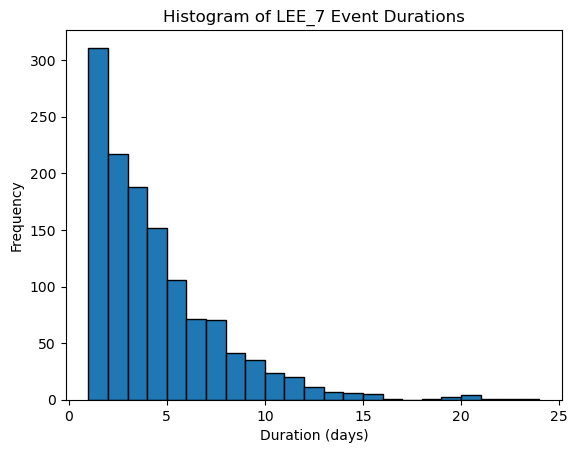

In [78]:
plt.hist(LEE_7['duration'], bins=range(1, LEE_7['duration'].max() + 2), edgecolor='black')
plt.xlabel('Duration (days)')
plt.ylabel('Frequency')
plt.title('Histogram of LEE_7 Event Durations')
plt.show()

In [59]:
# Save the results to CSV files
LEE_vl.to_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_vl_tst.csv', index=False)
LEE_7.to_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_7_tst.csv', index=False)
LEE_14.to_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_14_tst.csv', index=False)

In [44]:
def select_exemplary_entries(LEE_df, ESMs):
    exemplary_entries = []
    for esm in ESMs:
        esm_entries = LEE_df[LEE_df['ESM'] == esm]
        if not esm_entries.empty:
            exemplary_entry = esm_entries.iloc[0]  # Select the first entry for each ESM
            exemplary_entries.append(exemplary_entry)
    return pd.DataFrame(exemplary_entries)
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL', 'UKESM1-0-LL']

LEE_vl_subset = select_exemplary_entries(LEE_vl, ESMs)
LEE_vl_subset

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05 00:00:00.000000000,4,4,4,1,1366.529785,1366.529785,0.000000,1366.529785,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
250,2015-01-07,2015-01-08,2015-01-07 00:00:00.000000001,6,7,7,2,1348.572688,1338.035850,10.536838,2676.071700,BCC-CSM2-MR,BCC-CSM2-MR_r1i1p1f1,2015,7
336,2015-01-19,2015-01-19,2015-01-19 00:00:00.000000000,18,18,18,1,1329.501439,1329.501439,0.000000,1329.501439,CESM2,CESM2_r10i1p1f1,2015,19
591,2015-01-03,2015-01-03,2015-01-03 00:00:00.000000000,2,2,2,1,1365.869780,1365.869780,0.000000,1365.869780,EC-Earth3,EC-Earth3_r101i1p1f1,2015,3
5664,2015-01-06,2015-01-07,2015-01-06 00:00:00.000000001,5,6,6,2,1492.969327,1487.049487,5.919840,2974.098974,GFDL-ESM4,GFDL-ESM4_r1i1p1f1,2015,6
5759,2015-01-03,2015-01-04,2015-01-03 00:00:00.000000000,2,3,2,2,1396.891603,1386.392780,10.498823,2772.785559,KACE-1-0-G,KACE-1-0-G_r1i1p1f1,2015,3
5962,2015-01-13,2015-01-14,2015-01-13 00:00:00.000000001,12,13,13,2,1447.833652,1421.611586,26.222066,2843.223172,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r10i1p1f1,2015,13
6848,2015-01-03,2015-01-04,2015-01-03 00:00:00.000000000,2,3,2,2,1414.406285,1396.969339,17.436946,2793.938679,MRI-ESM2-0,MRI-ESM2-0_r1i1p1f1,2015,3
7270,2015-01-01,2015-01-01,2015-01-01 00:00:00.000000000,0,0,0,1,1342.845336,1342.845336,0.000000,1342.845336,TaiESM1,TaiESM1_r1i1p1f1,2015,1
7369,2015-01-04,2015-01-07,2015-01-04 00:00:00.000000002,3,6,5,4,1396.709279,1377.013698,12.743933,5508.054793,UKESM1-0-LL,UKESM1-0-LL_r10i1p1f2,2015,4


In [ ]:
def select_exemplary_entries(LEE_df, ESMs):
    exemplary_entries = []
    for esm in ESMs:
        esm_entries = LEE_df[LEE_df['ESM'] == esm]
        if not esm_entries.empty:
            exemplary_entry = esm_entries.iloc[0]  # Select the first entry for each ESM
            exemplary_entries.append(exemplary_entry)
    return pd.DataFrame(exemplary_entries)
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL', 'UKESM1-0-LL']

LEE_vl_subset = select_exemplary_entries(LEE_vl, ESMs)
LEE_vl_subset

,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
0,2015-01-18 12:00:00,2015-01-18 12:00:00,2015-01-18 12:00:00.000000000,1421582400000000000,1421582400000000000,1421582400000000000,17,17,17,1,1373.585419,1373.585419,0.000000,1373.585419,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2014,110
90,2015-01-29 12:00:00,2015-01-30 12:00:00,2015-01-29 12:00:00.000000001,2015-01-29 12:00:00,2015-01-30 12:00:00,2015-01-30 12:00:00,28,29,29,2,1405.949176,1403.680085,2.269091,2807.360171,BCC-CSM2-MR,BCC-CSM2-MR_r1i1p1f1,2014,121
140,2015-01-23 12:00:00,2015-01-23 12:00:00,2015-01-23 12:00:00.000000000,2015-01-23 00:00:00,2015-01-23 00:00:00,2015-01-23 00:00:00,22,22,22,1,1373.041431,1373.041431,0.000000,1373.041431,CESM2,CESM2_r10i1p1f1,2014,115
314,2015-01-03 12:00:00,2015-01-03 12:00:00,2015-01-03 12:00:00.000000000,1420286400000000000,1420286400000000000,1420286400000000000,2,2,2,1,1384.341608,1384.341608,0.000000,1384.341608,EC-Earth3,EC-Earth3_r101i1p1f1,2014,95
3518,2015-01-06 12:00:00,2015-01-07 12:00:00,2015-01-06 12:00:00.000000000,2015-01-06 12:00:00,2015-01-07 12:00:00,2015-01-06 12:00:00,5,6,5,2,1499.863135,1494.926396,4.936738,2989.852793,GFDL-ESM4,GFDL-ESM4_r1i1p1f1,2014,98
3577,2015-01-01 12:00:00,2015-01-02 12:00:00,2015-01-01 12:00:00.000000000,2015-01-03 12:00:00,2015-01-04 12:00:00,2015-01-03 12:00:00,0,1,0,2,1437.946950,1417.196820,20.750130,2834.393639,KACE-1-0-G,KACE-1-0-G_r1i1p1f1,2014,93
3683,2015-01-13 12:00:00,2015-01-14 12:00:00,2015-01-13 12:00:00.000000001,1421150400000000000,1421236800000000000,1421236800000000000,12,13,13,2,1452.940536,1412.376284,40.564252,2824.752569,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r10i1p1f1,2014,105
4264,2015-01-03 12:00:00,2015-01-04 12:00:00,2015-01-03 12:00:00.000000000,1420286400000000000,1420372800000000000,1420286400000000000,2,3,2,2,1408.839897,1395.603088,13.236809,2791.206176,MRI-ESM2-0,MRI-ESM2-0_r1i1p1f1,2014,95
4440,2015-01-04 12:00:00,2015-01-04 12:00:00,2015-01-04 12:00:00.000000000,2015-01-04 12:00:00,2015-01-04 12:00:00,2015-01-04 12:00:00,3,3,3,1,1403.191866,1403.191866,0.000000,1403.191866,TaiESM1,TaiESM1_r1i1p1f1,2014,96
4465,2015-01-02 12:00:00,2015-01-05 12:00:00,2015-01-02 12:00:00.000000002,2015-01-04 12:00:00,2015-01-07 12:00:00,2015-01-06 12:00:00,1,4,3,4,1462.266698,1417.861648,27.075770,5671.446594,UKESM1-0-LL,UKESM1-0-LL_r10i1p1f2,2014,94


In [55]:
LEE_all_comp = LEE_vl.copy()
LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
LEE_all_comp['Nr_of_runs'] = Nr_of_runs.values
LEE_all_comp['LEE_vl_dur_sum_esmnorm'] = LEE_all_comp['LEE_vl_dur_sum'] / LEE_all_comp['Nr_of_runs']

LEE_all_comp


,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,year,doy,Nr_of_runs,LEE_vl_dur_sum,LEE_vl_dur_sum_esmnorm
0,2015-01-05,2015-01-05,2015-01-05 00:00:00.000000000,4,4,4,1,1366.529785,1366.529785,0.000000,1366.529785,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5,3,499,166.333333
250,2015-01-07,2015-01-08,2015-01-07 00:00:00.000000001,6,7,7,2,1348.572688,1338.035850,10.536838,2676.071700,BCC-CSM2-MR,BCC-CSM2-MR_r1i1p1f1,2015,7,1,204,204.000000
336,2015-01-19,2015-01-19,2015-01-19 00:00:00.000000000,18,18,18,1,1329.501439,1329.501439,0.000000,1329.501439,CESM2,CESM2_r10i1p1f1,2015,19,3,538,179.333333
591,2015-01-03,2015-01-03,2015-01-03 00:00:00.000000000,2,2,2,1,1365.869780,1365.869780,0.000000,1365.869780,EC-Earth3,EC-Earth3_r101i1p1f1,2015,3,53,10134,191.207547
5448,2015-01-19,2015-01-24,2015-01-19 00:00:00.000000004,18,23,22,6,1431.030637,1386.637707,29.935717,8319.826244,ERA5_week,ERA5_hist_week,2015,19,1,174,174.000000
5538,2015-01-06,2015-01-06,2015-01-06 00:00:00.000000000,5,5,5,1,1344.162544,1344.162544,0.000000,1344.162544,ERA5_wwd,ERA5_hist_wwd,2015,6,1,231,231.000000
5664,2015-01-06,2015-01-07,2015-01-06 00:00:00.000000001,5,6,6,2,1492.969327,1487.049487,5.919840,2974.098974,GFDL-ESM4,GFDL-ESM4_r1i1p1f1,2015,6,1,173,173.000000
5759,2015-01-03,2015-01-04,2015-01-03 00:00:00.000000000,2,3,2,2,1396.891603,1386.392780,10.498823,2772.785559,KACE-1-0-G,KACE-1-0-G_r1i1p1f1,2015,3,3,483,161.000000
5962,2015-01-13,2015-01-14,2015-01-13 00:00:00.000000001,12,13,13,2,1447.833652,1421.611586,26.222066,2843.223172,MPI-ESM1-2-HR,MPI-ESM1-2-HR_r10i1p1f1,2015,13,10,1843,184.300000
6848,2015-01-03,2015-01-04,2015-01-03 00:00:00.000000000,2,3,2,2,1414.406285,1396.969339,17.436946,2793.938679,MRI-ESM2-0,MRI-ESM2-0_r1i1p1f1,2015,3,5,952,190.400000


In [56]:
# Add number of runs to the DataFrame
Nr_of_runs = LEE_vl.groupby('ESM')['ESM_run'].nunique()
LEE_vl['Nr_of_runs'] = LEE_vl['ESM'].map(Nr_of_runs)
LEE_vl

LEE_all_comp = LEE_vl.copy()


LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
LEE_all_comp['Nr_of_runs'] = Nr_of_runs.values

LEE_all_comp['LEE_vl_dur_sum_esmnorm'] = LEE_all_comp['LEE_vl_dur_sum'] / LEE_all_comp['Nr_of_runs']
# Remove most of the columns except for the ones we want to keep
LEE_all_comp = LEE_all_comp[['ESM', 'Nr_of_runs', 'LEE_vl_dur_sum', 'LEE_vl_dur_sum_esmnorm']]
LEE_all_comp

LEE_7_temp = LEE_7.copy()
LEE_7_temp['LEE_7_dur_sum'] = LEE_7_temp.groupby('ESM')['duration'].transform('sum')
LEE_7_temp = LEE_7_temp.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])
LEE_7_temp

# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_7_temp[['ESM', 'LEE_7_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_7_dur_sum_esmnorm'] = LEE_all_comp['LEE_7_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_14_temp = LEE_14.copy()
LEE_14_temp['LEE_14_dur_sum'] = LEE_14_temp.groupby('ESM')['duration'].transform('sum')
LEE_14_temp = LEE_14_temp.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])
# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_14_temp[['ESM', 'LEE_14_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_14_dur_sum_esmnorm'] = LEE_all_comp['LEE_14_dur_sum'] / LEE_all_comp['Nr_of_runs']

LEE_all_comp

,ESM,Nr_of_runs,LEE_vl_dur_sum,LEE_vl_dur_sum_esmnorm,LEE_7_dur_sum,LEE_7_dur_sum_esmnorm,LEE_14_dur_sum,LEE_14_dur_sum_esmnorm
0,ACCESS-CM2,3,499,166.333333,107,35.666667,21,7.000000
1,BCC-CSM2-MR,1,204,204.000000,67,67.000000,23,23.000000
2,CESM2,3,538,179.333333,144,48.000000,43,14.333333
3,EC-Earth3,53,10134,191.207547,2824,53.283019,838,15.811321
4,ERA5_week,1,174,174.000000,35,35.000000,7,7.000000
5,ERA5_wwd,1,231,231.000000,35,35.000000,7,7.000000
6,GFDL-ESM4,1,173,173.000000,41,41.000000,2,2.000000
7,KACE-1-0-G,3,483,161.000000,144,48.000000,34,11.333333
8,MPI-ESM1-2-HR,10,1843,184.300000,522,52.200000,193,19.300000
9,MRI-ESM2-0,5,952,190.400000,298,59.600000,100,20.000000


In [ ]:
# Add number of runs to the DataFrame
Nr_of_runs = LEE_vl.groupby('ESM')['ESM_run'].nunique()
LEE_vl['Nr_of_runs'] = LEE_vl['ESM'].map(Nr_of_runs)
LEE_vl

LEE_all_comp = LEE_vl.copy()


LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
LEE_all_comp['Nr_of_runs'] = Nr_of_runs.values

LEE_all_comp['LEE_vl_dur_avg'] = LEE_all_comp['LEE_vl_dur_sum'] / LEE_all_comp['Nr_of_runs']
# Remove most of the columns except for the ones we want to keep
LEE_all_comp = LEE_all_comp[['ESM', 'Nr_of_runs', 'LEE_vl_dur_sum', 'LEE_vl_dur_avg']]
LEE_all_comp

LEE_7_temp = LEE_7.copy()
LEE_7_temp['LEE_7_dur_sum'] = LEE_7_temp.groupby('ESM')['duration'].transform('sum')
LEE_7_temp = LEE_7_temp.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])
LEE_7_temp

# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_7_temp[['ESM', 'LEE_7_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_7_dur_avg'] = LEE_all_comp['LEE_7_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_14_temp = LEE_14.copy()
LEE_14_temp['LEE_14_dur_sum'] = LEE_14_temp.groupby('ESM')['duration'].transform('sum')
LEE_14_temp = LEE_14_temp.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])
# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_14_temp[['ESM', 'LEE_14_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_14_dur_avg'] = LEE_all_comp['LEE_14_dur_sum'] / LEE_all_comp['Nr_of_runs']

LEE_all_comp

,ESM,Nr_of_runs,LEE_1_dur_sum,LEE_1_dur_avg,LEE_7_dur_sum,LEE_7_dur_avg,LEE_14_dur_sum,LEE_14_dur_avg
0,ACCESS-CM2,3,125,41.666667,5.0,1.666667,NaN,NaN
1,BCC-CSM2-MR,1,100,100.000000,32.0,32.000000,6.0,6.000000
2,CESM2,3,288,96.000000,71.0,23.666667,3.0,1.000000
3,EC-Earth3,53,5155,97.264151,756.0,14.264151,125.0,2.358491
4,ERA5_week,1,152,152.000000,25.0,25.000000,2.0,2.000000
5,ERA5_wwd,1,218,218.000000,25.0,25.000000,2.0,2.000000
6,GFDL-ESM4,1,104,104.000000,11.0,11.000000,3.0,3.000000
7,KACE-1-0-G,3,202,67.333333,62.0,20.666667,7.0,2.333333
8,MPI-ESM1-2-HR,10,1026,102.600000,194.0,19.400000,46.0,4.600000
9,MRI-ESM2-0,5,301,60.200000,45.0,9.000000,3.0,0.600000


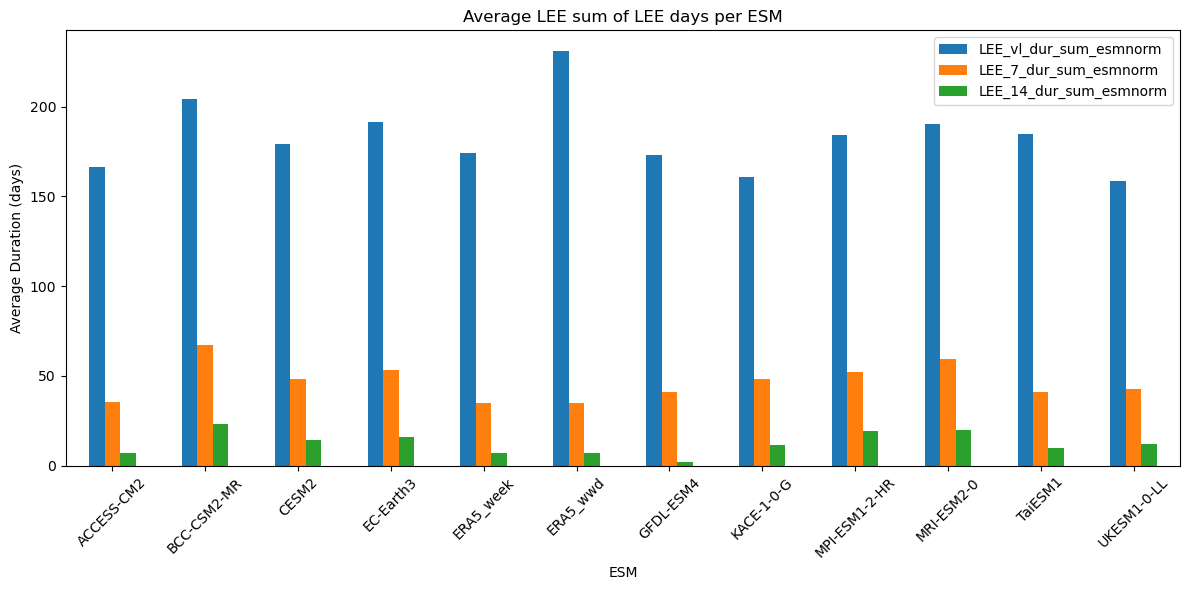

In [58]:
# Make a bar plot of the average durations
LEE_all_comp.set_index('ESM')[['LEE_vl_dur_sum_esmnorm', 'LEE_7_dur_sum_esmnorm', 'LEE_14_dur_sum_esmnorm']].plot(kind='bar', figsize=(12, 6))
plt.title('Average LEE sum of LEE days per ESM')
plt.ylabel('Average Duration (days)')
plt.xlabel('ESM')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/adjusted/LEE_durations_comparison.png', dpi=300)
plt.show()

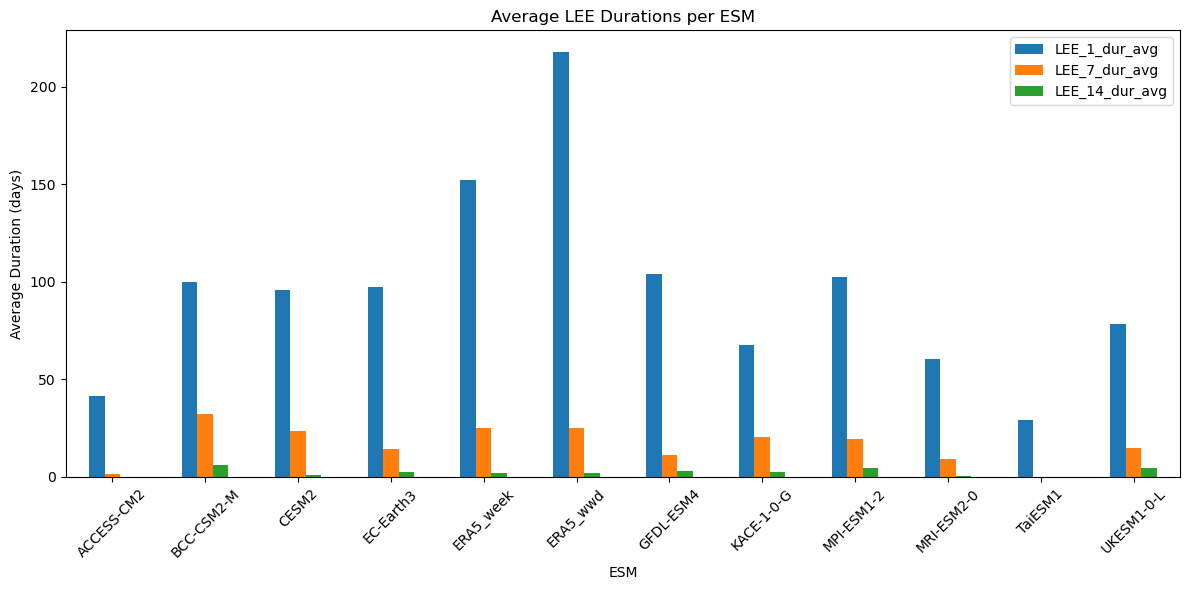

In [ ]:
# Make a bar plot of the average durations
LEE_all_comp.set_index('ESM')[['LEE_vl_dur_sum_esmnorm', 'LEE_7_dur_sum_esmnorm', 'LEE_14_dur_sum_esmnorm']].plot(kind='bar', figsize=(12, 6))
plt.title('Average LEE Durations per ESM')
plt.ylabel('Average Duration (days)')
plt.xlabel('ESM')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/adjusted/LEE_durations_comparison.png', dpi=300)
plt.show()

In [ ]:
LEE_vl

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
0,2015-01-18 12:00:00,2015-01-18 12:00:00,2015-01-18 12:00:00,17,17,17,1,1373.585419,1373.585419,0.000000,1373.585419,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2014,110
1,2015-10-21 12:00:00,2015-10-21 12:00:00,2015-10-21 12:00:00,110,110,110,1,1378.601098,1378.601098,0.000000,1378.601098,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,21
2,2015-11-04 12:00:00,2015-11-05 12:00:00,2015-11-04 12:00:00,124,125,124,2,1404.935534,1401.253278,3.682256,2802.506556,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,35
3,2015-12-16 12:00:00,2015-12-17 12:00:00,2015-12-16 12:00:00,166,167,166,2,1454.631376,1415.495103,39.136273,2830.990205,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,77
4,2016-12-12 12:00:00,2016-12-12 12:00:00,2016-12-12 12:00:00,344,344,344,1,1428.634773,1428.634773,0.000000,1428.634773,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5321,2023-12-21 12:00:00,2023-12-21 12:00:00,2023-12-21 12:00:00,1627,1627,1627,1,1378.105975,1378.105975,0.000000,1378.105975,UKESM1-0-L,UKESM1-0-LL_r9i1p1f,2023,82
5322,2023-12-23 12:00:00,2023-12-23 12:00:00,2023-12-23 12:00:00,1629,1629,1629,1,1409.127953,1409.127953,0.000000,1409.127953,UKESM1-0-L,UKESM1-0-LL_r9i1p1f,2023,84
5323,2024-01-25 12:00:00,2024-01-25 12:00:00,2024-01-25 12:00:00,1662,1662,1662,1,1390.731921,1390.731921,0.000000,1390.731921,UKESM1-0-L,UKESM1-0-LL_r9i1p1f,2023,117
5324,2024-11-14 12:00:00,2024-11-14 12:00:00,2024-11-14 12:00:00,1772,1772,1772,1,1399.713515,1399.713515,0.000000,1399.713515,UKESM1-0-L,UKESM1-0-LL_r9i1p1f,2024,45


In [19]:
LEE_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
0,2016-12-26 12:00:00,2016-12-27 12:00:00,2016-12-26 12:00:00.000000001,358,359,359,2,1293.962924,1292.593965,1.368960,2585.187929,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,87
1,2019-12-11 12:00:00,2019-12-16 12:00:00,2019-12-11 12:00:00.000000003,889,894,892,6,1465.163574,1341.823861,127.248195,8050.943167,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,72
2,2023-11-26 12:00:00,2023-11-27 12:00:00,2023-11-26 12:00:00.000000000,1602,1603,1602,2,1428.275821,1383.143353,45.132468,2766.286706,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2023,57
3,2023-12-09 12:00:00,2023-12-12 12:00:00,2023-12-09 12:00:00.000000002,1615,1618,1617,4,1424.306517,1358.127734,81.546865,5432.510936,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2023,70
4,2015-12-03 12:00:00,2015-12-04 12:00:00,2015-12-03 12:00:00.000000000,153,154,153,2,1388.150043,1378.049897,10.100146,2756.099795,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2015,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,2021-01-15 12:00:00,2021-01-15 12:00:00,2021-01-15 12:00:00.000000000,1106,1106,1106,1,1394.564043,1394.564043,0.000000,1394.564043,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2020,107
394,2021-11-15 12:00:00,2021-11-15 12:00:00,2021-11-15 12:00:00.000000000,1227,1227,1227,1,1356.543909,1356.543909,0.000000,1356.543909,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,46
395,2021-12-17 12:00:00,2021-12-22 12:00:00,2021-12-17 12:00:00.000000004,1259,1264,1263,6,1429.966126,1368.355265,54.386341,8210.131592,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,78
396,2022-01-01 12:00:00,2022-01-01 12:00:00,2022-01-01 12:00:00.000000000,1274,1274,1274,1,1194.529659,1194.529659,0.000000,1194.529659,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,93


In [20]:
# Identify events which are close to each other
for i in range(LEE_7.shape[0]-1):
    diff = LEE_7['date_start'][i + 1] - LEE_7['date_end'][i]
    if diff < pd.Timedelta(days=7) and diff > pd.Timedelta(days=0) and LEE_7['ESM_run'][i] == LEE_7['ESM_run'][i + 1]:
        print(diff, ':', i)
        print(LEE_7['date_end'][i], LEE_7['date_start'][i + 1])
        # print(i)

2 days 00:00:00 : 39
2020-12-19 12:00:00 2020-12-21 12:00:00
4 days 00:00:00 : 50
2015-01-07 12:00:00 2015-01-11 12:00:00
2 days 00:00:00 : 92
2019-12-06 12:00:00 2019-12-08 12:00:00
5 days 00:00:00 : 110
2017-12-24 12:00:00 2017-12-29 12:00:00
2 days 00:00:00 : 145
2021-12-21 12:00:00 2021-12-23 12:00:00
3 days 00:00:00 : 163
2021-01-05 12:00:00 2021-01-08 12:00:00
4 days 00:00:00 : 189
2020-12-14 12:00:00 2020-12-18 12:00:00
3 days 00:00:00 : 197
2019-12-30 12:00:00 2020-01-02 12:00:00
3 days 00:00:00 : 225
2016-12-26 12:00:00 2016-12-29 12:00:00
6 days 00:00:00 : 245
2020-02-06 12:00:00 2020-02-12 12:00:00
2 days 00:00:00 : 251
2015-12-22 12:00:00 2015-12-24 12:00:00
5 days 00:00:00 : 262
2019-12-27 12:00:00 2020-01-01 12:00:00
2 days 00:00:00 : 263
2020-01-03 12:00:00 2020-01-05 12:00:00
2 days 00:00:00 : 264
2020-01-07 12:00:00 2020-01-09 12:00:00
5 days 00:00:00 : 265
2020-01-17 12:00:00 2020-01-22 12:00:00
2 days 00:00:00 : 273
2021-12-19 12:00:00 2021-12-21 12:00:00
3 days 00:0

In [21]:
LEE_14

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
0,2019-12-15 12:00:00,2019-12-15 12:00:00,2019-12-15 12:00:00.000000000,893,893,893,1,1416.849831,1416.849831,0.000000,1416.849831,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,76
1,2019-12-29 12:00:00,2019-12-30 12:00:00,2019-12-29 12:00:00.000000000,907,908,907,2,1433.452540,1421.276535,12.176005,2842.553070,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,90
2,2020-01-03 12:00:00,2020-01-04 12:00:00,2020-01-03 12:00:00.000000000,912,913,912,2,1433.633953,1431.626378,2.007575,2863.252756,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,95
3,2020-01-07 12:00:00,2020-01-07 12:00:00,2020-01-07 12:00:00.000000000,916,916,916,1,1388.522488,1388.522488,0.000000,1388.522488,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,99
4,2021-12-30 12:00:00,2022-01-04 12:00:00,2021-12-30 12:00:00.000000001,1272,1277,1273,6,1439.205691,1252.262139,132.987416,7513.572832,EC-Earth3,EC-Earth3_r109i1p1f1,2021,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2022-12-16 12:00:00,2022-12-28 12:00:00,2022-12-16 12:00:00.000000007,1440,1452,1447,13,1513.094675,1365.416039,98.926988,17750.408504,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2022,77
62,2017-12-25 12:00:00,2017-12-25 12:00:00,2017-12-25 12:00:00.000000000,539,539,539,1,1341.950434,1341.950434,0.000000,1341.950434,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2017,86
63,2019-01-01 12:00:00,2019-01-01 12:00:00,2019-01-01 12:00:00.000000000,728,728,728,1,1413.219369,1413.219369,0.000000,1413.219369,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2018,93
64,2019-12-08 12:00:00,2019-12-09 12:00:00,2019-12-08 12:00:00.000000000,886,887,886,2,1150.825543,1118.753634,32.071909,2237.507267,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2019,69


In [22]:
LEE_7[39:43]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
39,2020-12-19 12:00:00,2020-12-19 12:00:00,2020-12-19 12:00:00,1079,1079,1079,1,1423.572743,1423.572743,0.0,1423.572743,EC-Earth3,EC-Earth3_r108i1p1f1,2020,80
40,2020-12-21 12:00:00,2020-12-21 12:00:00,2020-12-21 12:00:00,1081,1081,1081,1,1188.854333,1188.854333,0.0,1188.854333,EC-Earth3,EC-Earth3_r108i1p1f1,2020,82
41,2016-11-22 12:00:00,2016-11-22 12:00:00,2016-11-22 12:00:00,324,324,324,1,1375.515610,1375.515610,0.0,1375.515610,EC-Earth3,EC-Earth3_r109i1p1f1,2016,53
42,2019-12-11 12:00:00,2019-12-11 12:00:00,2019-12-11 12:00:00,889,889,889,1,1401.143383,1401.143383,0.0,1401.143383,EC-Earth3,EC-Earth3_r109i1p1f1,2019,72


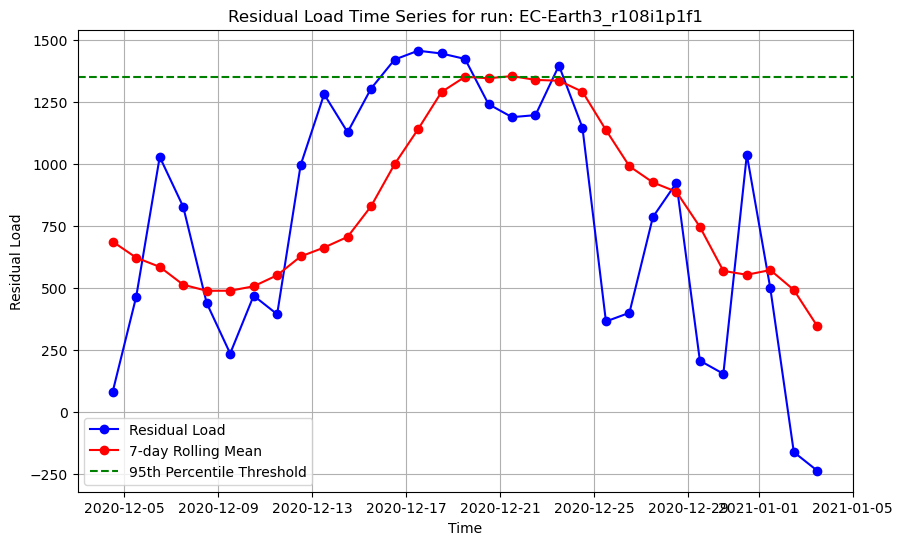

In [23]:
LEE = LEE_7
evt = 39
box = 15


# Extract the data for the specified range
RL_plot = RL.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]

# Plot using matplotlib
plt.figure(figsize=(10, 6))
plt.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color='b', label='Residual Load')
plt.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color='r', label='7-day Rolling Mean')
# Threshold
plt.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')
plt.xlabel('Time')
plt.ylabel('Residual Load')
plt.title(f'Residual Load Time Series for run: {LEE['ESM_run'][evt]}')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Old code without rolling mean

minDuration = 7 # days
t = RL['time'].values

# Find all LEE events of duration >= minDuration
for i in range(len(RL.ESM)):
    
    for ev in range(1,n_events+1):
        # print(ev)
        event_duration = (events[i] == ev).sum() 
        if event_duration < minDuration:
            continue
        print(RL.ESM_run[i].values)
        # print(event_duration)
        LEE['date_start'].append(t[np.where(events[i] == ev)[0][0]])
        LEE['date_end'].append(t[np.where(events[i] == ev)[0][-1]])
        LEE['ESM'].append(str(RL.ESM[i].values))
        LEE['ESM_run'].append(str(RL.ESM_run[i].values))
        LEE['winter'].append(RL.winter_year[i].values)
        LEE_start = np.where(t==LEE['date_start'][-1])[0][0]
        # print(LEE_start)
        LEE_end = np.where(t==LEE['date_end'][-1])[0][0]
        # print(LEE_end)
        LEE['index_start'].append(LEE_start)
        LEE['index_end'].append(LEE_end)
        RL_run = RL.sel(ESM_run = RL.ESM_run[i]).values # RL timeseries of the event
        RL_LEE = RL_run[LEE_start : LEE_end + 1] # RL timeseries
        print(RL_LEE)
        LEE_peak = np.argmax(RL_LEE)
        print('LEE Peak', LEE_peak)
        LEE['date_peak'].append(LEE['date_start'][-1] + LEE_peak)
        print(LEE['date_peak'][-1])
        LEE['index_peak'].append(LEE_start + LEE_peak)
        print(LEE['index_peak'][-1])
        # LEE Duration
        LEE['duration'].append(len(RL_LEE))
        print('Duration:', LEE['duration'][-1])
        # LEE Intensity metrics
        LEE['RL_max'].append(RL_LEE[LEE_peak])
        print('RL_max:', LEE['RL_max'][-1])
        LEE['RL_mean'].append(RL_LEE.mean())
        print('RL_mean:', LEE['RL_mean'][-1])
        LEE['RL_var'].append(np.sqrt(RL_LEE.var()))
        print('RL_var:', LEE['RL_var'][-1])
        LEE['RL_cumulative'].append(RL_LEE.sum()) # energy deficit or drought severity
        print('RL_cumulative:', LEE['RL_cumulative'][-1])
        # break
    

UKESM1-0-LL_r4i1p1f2
[1362.02202    1426.84594281 1403.19686189 1411.79696924 1411.13093176
 1438.61170868 1382.75334765]
LEE Peak 5
2015-01-23T12:00:00.000000005
27
Duration: 7
RL_max: 1438.6117086791608
RL_mean: 1405.1939688609311
RL_var: 24.011269786239097
RL_cumulative: 9836.357782026518
UKESM1-0-LL_r4i1p1f2
[1355.6347917  1400.32245918 1373.75876901 1390.95103538 1406.78897509
 1423.62005802 1380.29133016]
LEE Peak 5
2019-12-02T12:00:00.000000005
885
Duration: 7
RL_max: 1423.6200580209427
RL_mean: 1390.1953455057615
RL_var: 20.902398680347783
RL_cumulative: 9731.36741854033
UKESM1-0-LL_r4i1p1f2
[1373.4060436  1401.99949651 1493.61290014 1482.99039703 1438.34592673
 1365.58574216 1368.49068761 1484.80195225]
LEE Peak 2
2020-12-19T12:00:00.000000002
1081
Duration: 8
RL_max: 1493.6129001439044
RL_mean: 1426.1541432545234
RL_var: 52.116052006315186
RL_cumulative: 11409.233146036187
UKESM1-0-LL_r4i1p1f2
[1370.62007933 1388.50287797 1429.56230377 1398.48584854 1377.94712584
 1409.565378

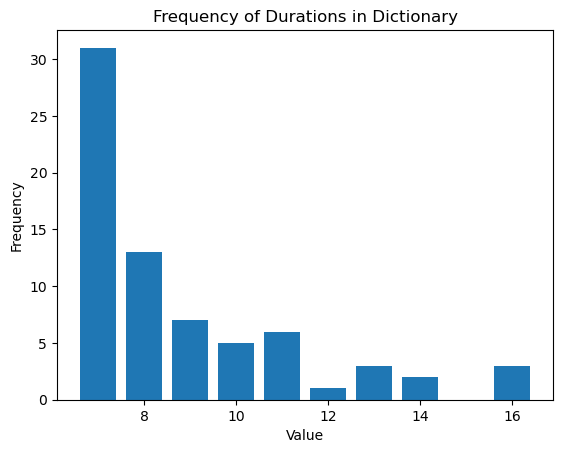

In [28]:
from collections import Counter
# Count how often each value occurs
value_counts = Counter(LEE['duration'])

# Extract the values and their counts
values = list(value_counts.keys())
counts = list(value_counts.values())

# Create a bar plot
plt.bar(values, counts)

# Add title and labels
plt.title('Frequency of Durations in Dictionary')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [29]:
value_counts

Counter({7: 31, 8: 13, 9: 7, 11: 6, 10: 5, 16: 3, 13: 3, 14: 2, 12: 1})

In [32]:
from collections import Counter
# Count how often each value occurs
value_counts = Counter(LEE['ESM'])

# Extract the values and their counts
values = list(value_counts.keys())
counts = list(value_counts.values())

runs = dict(model = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL'],
         run = [3, 1, 3, 58, 1, 1, 3, 10, 5, 1, 19])

df = pd.DataFrame(runs)
df['count'] = df['model'].map(value_counts)
df['relative'] = df['count'] / df['run']
df

,model,run,count,relative
0,ACCESS-CM2,3,211,70.333333
1,BCC-CSM2-MR,1,67,67.000000
2,CESM2,3,91,30.333333
3,EC-Earth3,58,2240,38.620690
4,EC-Earth3-Veg,1,0,0.000000
5,GFDL-ESM4,1,52,52.000000
6,KACE-1-0-G,3,81,27.000000
7,MPI-ESM1-2-HR,10,779,77.900000
8,MRI-ESM2-0,5,166,33.200000
9,TaiESM1,1,48,48.000000


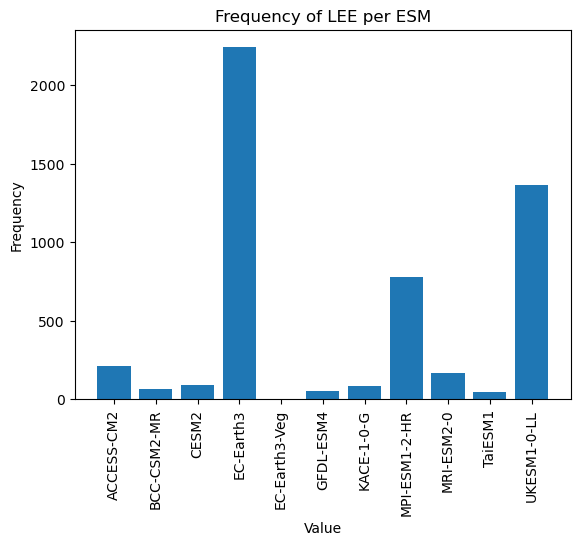

In [46]:
# Create a bar plot
plt.bar(df['model'], df['count'])

# Add title and labels
plt.title('Frequency of LEE per ESM')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
# Show the plot
plt.show()

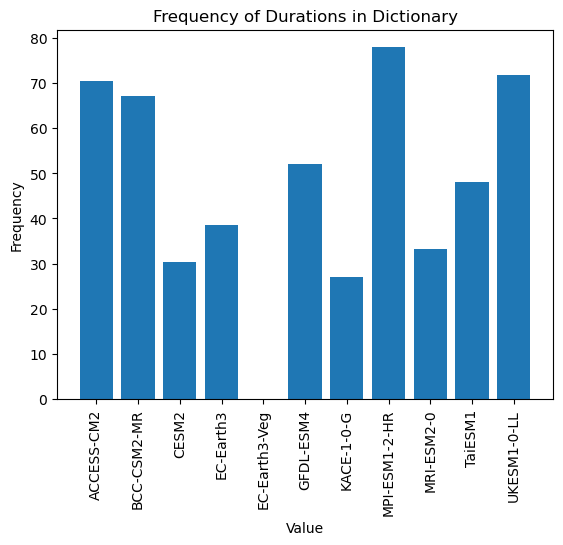

In [ ]:
# Create a bar plot
plt.bar(df['model'], df['relative'])

# Add title and labels
plt.title('Mean Frequency of LEE in ESM')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
# Show the plot
plt.show()

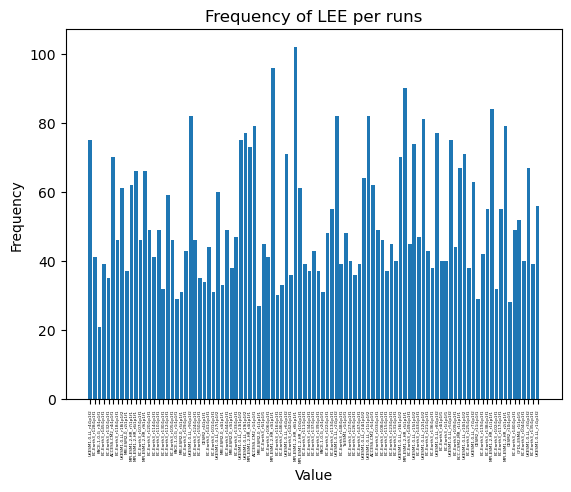

In [47]:
from collections import Counter
# Count how often each value occurs
value_counts = Counter(LEE['ESM_run'])

# Extract the values and their counts
values = list(value_counts.keys())
counts = list(value_counts.values())

# Create a bar plot
plt.bar(values, counts)

# Add title and labels
plt.title('Frequency of LEE per runs')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks(rotation=90, fontsize=3)

# Show the plot
plt.show()

In [22]:
LEE['duration'][0]

1

In [17]:
len(LEE['date_start'])

5098

In [ ]:
# RL_run = RL.sel(ESM_run = RL.ESM_run[]).values # RL timeseries of the event
# RL_LEE = RL_run[tt_start : tt_end + 1] # RL timeseries
# print(RL_LEE)

[ 158.64572976 1101.632428   1192.03642035 1222.05022456 1166.72837583
 1201.17447734 1294.25195143 1276.89910241 1370.90321842  983.0898243
 1093.8583566   768.77892421 1256.19375004 1013.36348419  969.54925136
  474.07758187]


In [19]:
for i in range(len(LEE['date_start'])):
    print(LEE['ESM'][i])
    print(LEE['ESM_run'][i])
    print(LEE['winter'][i])
    print(LEE['date_start'][i])
    print(LEE['date_end'][i])


# np.unique(LEE['date_start'])

UKESM1-0-LL
UKESM1-0-LL_r18i1p1f2
[2014 2014 2014 ... 2024 2024 2024]
2016-01-14T12:00:00.000000000
2016-01-24T12:00:00.000000000
UKESM1-0-LL
UKESM1-0-LL_r13i1p1f2
[2014 2014 2014 ... 2024 2024 2024]
2016-01-08T12:00:00.000000000
2016-01-23T12:00:00.000000000
UKESM1-0-LL
UKESM1-0-LL_r19i1p1f2
[2014 2014 2014 ... 2024 2024 2024]
2019-01-21T12:00:00.000000000
2019-01-30T12:00:00.000000000
MPI-ESM1-2-HR
MPI-ESM1-2-HR_r4i1p1f1
[2014 2014 2014 ... 2024 2024 2024]
2020-12-02T12:00:00.000000000
2020-12-15T12:00:00.000000000
MPI-ESM1-2-HR
MPI-ESM1-2-HR_r10i1p1f1
[2014 2014 2014 ... 2024 2024 2024]
2023-12-01T12:00:00.000000000
2023-12-11T12:00:00.000000000
EC-Earth3
EC-Earth3_r134i1p1f1
[2014 2014 2014 ... 2024 2024 2024]
2021-12-29T12:00:00.000000000
2022-01-07T12:00:00.000000000
EC-Earth3
EC-Earth3_r113i1p1f1
[2014 2014 2014 ... 2024 2024 2024]
2018-12-21T12:00:00.000000000
2018-12-31T12:00:00.000000000
UKESM1-0-LL
UKESM1-0-LL_r2i1p1f2
[2014 2014 2014 ... 2024 2024 2024]
2018-01-01T12:00:00.

In [ ]:
# # np.where(t==LEE['date_start'][1])[0][0]
# tt_start = np.where(t==LEE['date_start'][1])[0][0]
# print(tt_start)
# tt_end = np.where(t==LEE['date_end'][1])[0][0]
# print(tt_end)
# LEE['index_start'].append(tt_start)
# LEE['index_end'].append(tt_end)
# RL_run = RL.sel(ESM_run = RL.ESM_run[1]).values # RL timeseries of the event
# RL_LEE = RL_run[tt_start : tt_end + 1] # RL timeseries
# print(RL_LEE)
# tt_peak = np.argmax(RL_LEE)
# # print(tt_peak)

189
204
[ 866.01605503  978.79976812  978.1085741   766.14326346  313.90692019
  621.47068534 1062.72773477 1327.46688984 1367.54710415 1193.53293817
 1053.02655528 1208.94265281  981.18107694  625.57649208 1082.50865648
  979.61998489]


In [ ]:
# maybe:
LEE['prod_max'] = []
LEE['prod_mean'] = []
LEE['prod_var'] = []
LEE['prod_cumulative'] = []
LEE['demand_max'] = []
LEE['demand_mean'] = []
LEE['demand_var'] = []
LEE['demand_cumulative'] = []
LEE['pot_max'] = []
LEE['pot_mean'] = []
LEE['pot_var'] = []
LEE['pot_cumulative'] = []

189
204


In [ ]:
'''
# Link heat waves that occur before and after a short gap (gap must be no longer than maxGap)
if joinAcrossGaps:
    # Calculate gap length for each consecutive pair of events
    gaps = np.array(LEE['time_start'][1:]) - np.array(LEE['time_end'][0:-1]) - 1
    if len(gaps) > 0:
        while gaps.min() <= maxGap:
            # Find first short gap
            ev = np.where(gaps <= maxGap)[0][0]
            # Extend first LEE to encompass second LEE (including gap)
            LEE['time_end'][ev] = LEE['time_end'][ev+1]
            # Remove second event from record
            del LEE['time_start'][ev+1]
            del LEE['time_end'][ev+1]
            # Calculate gap length for each consecutive pair of events
            gaps = np.array(LEE['time_start'][1:]) - np.array(LEE['time_end'][0:-1]) - 1
            if len(gaps) == 0:
                break
'''


'''
# Fix categories
tt_peakCat = np.argmax(LEE_relThreshNorm)
cats = np.floor(1. + LEE_relThreshNorm)
LEE['category'].append(categories[np.min([cats[tt_peakCat], 4]).astype(int) - 1])
LEE['duration_moderate'].append(np.sum(cats == 1.))
LEE['duration_strong'].append(np.sum(cats == 2.))
LEE['duration_severe'].append(np.sum(cats == 3.))
LEE['duration_extreme'].append(np.sum(cats >= 4.))
'''


array([1244.5034235 , 1321.65036059, 1314.3476472 , ..., 1431.4471573 ,
       1439.09306053, 1391.82968321])

## Calculation of SRLI

In [ ]:
import xarray as xr
import dask.array as da
import numpy as np
from scipy.stats import norm

def compute_srli(data_array, eps=1e-4): #1/(2*180180)
    """
    Compute the SRLI (Standardised Residual Load Index) over the full dataset,
    while keeping the shape and metadata of the input xarray DataArray.

    Parameters:
    - data_array (xarray.DataArray): input residual load (shape: ESM_run x time)

    Returns:
    - srli (xarray.DataArray): same shape as input, with SRLI values
    """
    # Compute ECDF ranks using Dask
    def ecdf_rank(values):
        # Sort the values
        sorted_vals = np.sort(values)
        # Use searchsorted to get the ECDF
        ranks = np.searchsorted(sorted_vals, values, side="right")
        ecdf_vals = (ranks + 1) / (len(values) + 1)
        return np.clip(ecdf_vals, eps, 1 - eps)  # avoid 0 and 1
    
    
    # Compute ECDF on full dataset (across all dimensions)
    ecdf = data_array.copy(data=da.map_blocks(
        lambda block: ecdf_rank(block.flatten()).reshape(block.shape),
        data_array.data,
        dtype=float
    ))

    # Apply inverse normal CDF (probit function)
    srli = xr.apply_ufunc(
        norm.ppf,
        ecdf,
        dask='parallelized',
        output_dtypes=[float]
    )

    # Rename the result
    srli.name = "SRLI"

    return srli


In [89]:
srli_tst = compute_srli(RL)

In [ ]:
# Time series of "True" when threshold is exceeded, "False" otherwise

exceed_bool = xr.where(srli_tst.values > 1.64, True, False)

# Find contiguous regions of exceed_bool = True
events, n_events = ndimage.label(exceed_bool)

In [74]:
events

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

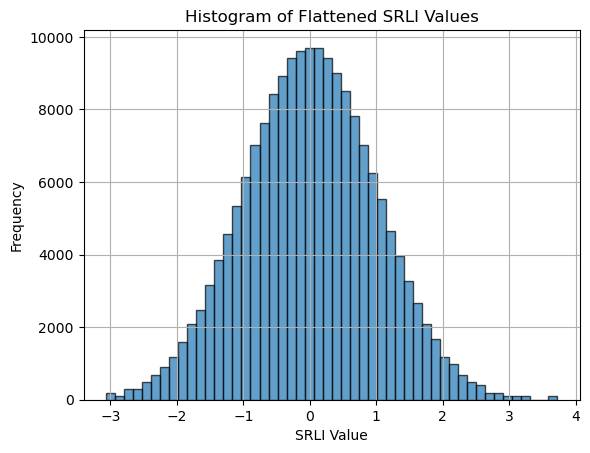

In [90]:
import matplotlib.pyplot as plt

# Flatten the SRLI values and create a histogram
plt.hist(srli_tst.values.flatten(), bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('SRLI Value')
plt.ylabel('Frequency')
plt.title('Histogram of Flattened SRLI Values')
plt.grid(True)
plt.show()

## Old Code

#### SRLI for individual run

In [ ]:
import numpy as np
from scipy.stats import norm

def calculate_srli(residual_load_series):
    """
    Calculate the Standardised Residual Load Index (SRLI) from a series of residual load values.
    
    Parameters:
    - residual_load_series: pd.Series or np.array of residual load values

    Returns:
    - srli_values: np.array of SRLI values
    """
    # Ensure data is a numpy array
    data = np.array(residual_load_series)
    
    # Rank the data to calculate the empirical CDF
    sorted_data = np.sort(data)
    ranks = np.searchsorted(sorted_data, data, side='right')
    empirical_cdf = (ranks + 1) / (len(data) + 1)

    # Apply the inverse of the standard normal CDF (probit)
    srli_values = norm.ppf(empirical_cdf)
    
    return srli_values